# Sezione 6 — Louvain: Phase 1 & Phase 2
## Applicata alla rete `climate_19` con **igraph**

Questo notebook sviluppa la **Sezione 6** del tutorial NS13 (*"DA FARE"*)
applicandola integralmente alla rete `climate_19.graphml` usando igraph.

### Struttura
1. Caricamento dati e toy graph
2. **Phase 1** — ottimizzazione locale di Q (implementazione da zero)
3. **Phase 2** — costruzione della supernetwork
4. Louvain completo su `climate_19` con `g.community_multilevel()`
5. Stabilità: 30 run con seed diversi (Q e numero di comunità)
6. Confronto con la partizione ground-truth A/B (NMI, ARI)
7. Analisi delle comunità trovate: dimensioni, densità, mapping su A/B
8. Interpretazione


---
## 1. Caricamento dati

Carichiamo `climate_19.graphml` con igraph e costruiamo un **toy graph** a 8 nodi
(due $K_4$ collegati da un bridge) per il walkthrough delle due fasi.


In [3]:
import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# ── Rete climate_19 ──────────────────────────────────────────────────────
g = ig.Graph.Read_GraphML(r"C:\Users\giuli\OneDrive\Documenti\UNI\MAGISTRALE\AnalVisual\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")
if g.is_directed():
    g = g.as_undirected(combine_edges="first")

N = g.vcount()
E = g.ecount()
group_attr = g.vs["group"]
hier_attr  = g.vs["hierarchy"]

idx_A = [v.index for v in g.vs if v["group"] == "A"]
idx_B = [v.index for v in g.vs if v["group"] == "B"]
sub_idx = {lbl: [v.index for v in g.vs if v["hierarchy"] == lbl]
           for lbl in ["A_CORE","A_PERIPHERY","B_CORE","B_PERIPHERY"]}

print(f"climate_19 — Nodi: {N:,}  Archi: {E:,}  Densità: {g.density():.6f}")
print(f"Comunità A: {len(idx_A):,}  |  B: {len(idx_B):,}")


climate_19 — Nodi: 16,639  Archi: 50,605  Densità: 0.000366
Comunità A: 7,409  |  B: 9,230


In [4]:
# ── Toy graph: due K4 collegati da un bridge ─────────────────────────────
# Nodi 0-3 → cluster sinistro, nodi 4-7 → cluster destro, arco 3-4 = bridge
toy = ig.Graph()
toy.add_vertices(8)
edges_left  = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]          # K4 sinistra
edges_right = [(4,5),(4,6),(4,7),(5,6),(5,7),(6,7)]          # K4 destra
bridge      = [(3,4)]
toy.add_edges(edges_left + edges_right + bridge)

print(f"Toy graph — Nodi: {toy.vcount()}  Archi: {toy.ecount()}")
print(f"Densità: {toy.density():.4f}")
print(f"Q (partizione ottima {{0-3}}|{{4-7}}): "
      f"{toy.modularity(toy.community_multilevel().membership):.4f}")


Toy graph — Nodi: 8  Archi: 13
Densità: 0.4643
Q (partizione ottima {0-3}|{4-7}): 0.4231


---
## 2. Phase 1 — Ottimizzazione locale di Q (implementazione da zero)

### Pseudocode
```
INIZIALIZZA  ogni nodo nella propria comunità
RIPETI fino a convergenza:
    per ogni nodo i (in ordine casuale):
        per ogni comunità C vicina a i:
            calcola ΔQ se i si sposta da C_attuale a C
        sposta i nella comunità con il maggior ΔQ > 0
```

### Formula ΔQ (Blondel et al. 2008)

$$\Delta Q = \frac{k_{i,C}}{L} - \frac{k_i \cdot K_C}{2L^2}$$

dove:
- $k_{i,C}$ = archi tra nodo $i$ e la comunità destinazione $C$
- $k_i$ = grado di $i$
- $K_C$ = somma dei gradi dei nodi in $C$  
- $L$ = numero totale di archi

La formula confronta i guadagni dello spostamento verso $C$ con la penalità
del configuration model (proporzionale al grado).


In [5]:
def phase1_sweep(g, community_of=None, verbose=False):
    """
    Esegue UN sweep completo di Phase 1 su tutti i nodi in ordine random.
    
    Parametri
    ---------
    g            : igraph.Graph
    community_of : list[int] | None  — membership iniziale (None = ogni nodo nella propria)
    verbose      : bool — stampa ogni spostamento
    
    Ritorna
    -------
    community_of : list[int] aggiornata
    n_moves      : numero di nodi spostati
    delta_Q      : guadagno totale di Q nello sweep
    """
    n = g.vcount()
    L = g.ecount()
    if L == 0:
        return list(range(n)), 0, 0.0

    if community_of is None:
        community_of = list(range(n))   # ogni nodo = comunità propria

    degree   = g.degree()               # degree[i] = grado nodo i
    # somma gradi per comunità
    K = defaultdict(float)
    for i, c in enumerate(community_of):
        K[c] += degree[i]

    order   = list(range(n))
    rng.shuffle(order)
    n_moves = 0
    dQ_tot  = 0.0

    for i in order:
        c_old    = community_of[i]
        k_i      = degree[i]

        # vicini di i raggruppati per comunità
        nbr_comm = defaultdict(int)
        for j in g.neighbors(i):
            nbr_comm[community_of[j]] += 1

        best_c   = c_old
        best_dQ  = 0.0

        for c_new, k_i_in_c in nbr_comm.items():
            if c_new == c_old:
                continue
            # ΔQ di spostamento verso c_new
            dQ = k_i_in_c / L - k_i * K[c_new] / (2 * L ** 2)
            if dQ > best_dQ:
                best_dQ = dQ
                best_c  = c_new

        if best_c != c_old:
            # esegui lo spostamento
            K[c_old] -= k_i
            K[best_c] += k_i
            community_of[i] = best_c
            n_moves += 1
            dQ_tot  += best_dQ
            if verbose:
                print(f"  Nodo {i}: comunità {c_old} → {best_c}  (ΔQ={best_dQ:+.5f})")

    return community_of, n_moves, dQ_tot


In [ ]:
def full_phase1(g, verbose=False):
    """
    Esegue sweep ripetuti di Phase 1 fino a convergenza (nessuno spostamento).
    Ritorna il membership finale e la history (sweep, n_moves, dQ).
    """
    community_of = list(range(g.vcount()))
    history = []
    sweep = 0
    while True:
        community_of, n_moves, dQ = phase1_sweep(g, community_of, verbose=False)
        history.append({'sweep': sweep, 'n_moves': n_moves, 'dQ': round(dQ, 6)})
        if verbose:
            print(f"Sweep {sweep}: {n_moves} spostamenti, ΔQ totale = {dQ:+.6f}")
        sweep += 1
        if n_moves == 0:
            break
    return community_of, history


In [ ]:
# ── Walkthrough sul toy graph ─────────────────────────────────────────────
print("=== Phase 1 sul toy graph (2×K4 + bridge) ===")
print()
memb_toy, hist_toy = full_phase1(toy, verbose=True)

# Compatta gli id comunità (potrebbero essere sparsi)
unique_c = sorted(set(memb_toy))
remap    = {c: i for i, c in enumerate(unique_c)}
memb_toy = [remap[c] for c in memb_toy]

print(f"\nMembership finale: {memb_toy}")
print(f"Comunità trovate : {sorted(set(memb_toy))}")
print(f"Q finale         : {toy.modularity(memb_toy):.4f}")
print()
print("Sweep history:")
display(pd.DataFrame(hist_toy))


In [ ]:
# ── Visualizzazione partizione Phase 1 sul toy ───────────────────────────
colors_map = {0: "steelblue", 1: "tomato", 2: "seagreen", 3: "goldenrod"}
node_colors = [colors_map[c] for c in memb_toy]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafo colorato per comunità
layout = toy.layout("kk")
coords = layout.coords
xs = [c[0] for c in coords]; ys = [c[1] for c in coords]

for e in toy.get_edgelist():
    x0, y0 = coords[e[0]]; x1, y1 = coords[e[1]]
    axes[0].plot([x0,x1],[y0,y1], color="grey", linewidth=1.2, zorder=1)
axes[0].scatter(xs, ys, c=node_colors, s=400, zorder=2, edgecolors="white", linewidths=1.5)
for i, (x,y) in enumerate(coords):
    axes[0].text(x, y, str(i), ha="center", va="center", fontsize=9, color="white", fontweight="bold")
axes[0].set_title("Toy graph — Phase 1 result")
axes[0].axis("off")

patches = [mpatches.Patch(color=colors_map[c], label=f"Comunità {c}")
           for c in sorted(set(memb_toy))]
axes[0].legend(handles=patches, loc="upper left", fontsize=9)

# ΔQ per sweep
ax2 = axes[1]
sweeps = [h["sweep"] for h in hist_toy]
dqs    = [h["dQ"] for h in hist_toy]
ax2.bar(sweeps, dqs, color="steelblue", edgecolor="white")
ax2.set_xlabel("Sweep"); ax2.set_ylabel("ΔQ totale")
ax2.set_title("Phase 1 — guadagno di Q per sweep (toy)")
ax2.set_xticks(sweeps)
plt.tight_layout(); plt.show()


---
## 3. Phase 2 — Costruzione della Supernetwork

Dopo Phase 1 ogni comunità diventa un **super-nodo**.
- Gli archi *tra* due comunità → arco pesato nella supernetwork (peso = conteggio)
- Gli archi *interni* a una comunità → self-loop sul super-nodo

Phase 1 viene poi rieseguita sulla supernetwork. Il ciclo si ripete fino a
quando Q non migliora più.


In [ ]:
def build_supernetwork(g, membership):
    """
    Costruisce la supernetwork igraph dopo un Phase 1.
    
    Ritorna
    -------
    H     : igraph.Graph pesato (i self-loop sono memorizzati come attributo 'self_weight')
    sizes : dict {super_id: numero nodi originali}
    """
    k = max(membership) + 1
    H = ig.Graph(n=k)
    H.vs["size"] = [0] * k
    for i, c in enumerate(membership):
        H.vs[c]["size"] += 1

    # conta archi inter e intra
    inter = defaultdict(int)
    intra = defaultdict(int)
    for e in g.get_edgelist():
        cu, cv = membership[e[0]], membership[e[1]]
        if cu == cv:
            intra[cu] += 1
        else:
            key = (min(cu,cv), max(cu,cv))
            inter[key] += 1

    # self-loop weights come attributo di nodo
    H.vs["self_weight"] = [intra.get(c, 0) for c in range(k)]

    # archi tra super-nodi
    for (cu, cv), w in inter.items():
        H.add_edge(cu, cv, weight=w)

    return H


In [ ]:
# ── Walkthrough Phase 2 sul toy ──────────────────────────────────────────
H_toy = build_supernetwork(toy, memb_toy)

print("=== Supernetwork dopo Phase 1 (toy graph) ===")
print(f"Super-nodi : {H_toy.vcount()}")
print(f"Super-archi: {H_toy.ecount()} (escl. self-loop)")
print()
print("Self-loop weights (archi interni per comunità):")
for i in range(H_toy.vcount()):
    print(f"  Super-nodo {i}: {H_toy.vs[i]['self_weight']} archi interni, "
          f"{H_toy.vs[i]['size']} nodi originali")
print()
print("Archi tra super-nodi:")
for e in H_toy.es:
    print(f"  ({e.source}, {e.target}) — peso {e['weight']}")


In [ ]:
# ── Visualizzazione originale + supernetwork ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sinistra: grafo originale colorato
for e in toy.get_edgelist():
    x0,y0 = coords[e[0]]; x1,y1 = coords[e[1]]
    axes[0].plot([x0,x1],[y0,y1], color="grey", linewidth=1.2, zorder=1)
axes[0].scatter(xs, ys, c=node_colors, s=400, zorder=2, edgecolors="white", linewidths=1.5)
for i,(x,y) in enumerate(coords):
    axes[0].text(x, y, str(i), ha="center", va="center",
                 fontsize=9, color="white", fontweight="bold")
axes[0].set_title("Grafo originale (Phase 1 communities)")
axes[0].axis("off")
axes[0].legend(handles=patches, loc="upper left", fontsize=9)

# Destra: supernetwork
k_super = H_toy.vcount()
angles  = [2*np.pi*i/k_super for i in range(k_super)]
sx = [np.cos(a)*1.5 for a in angles]
sy = [np.sin(a)*1.5 for a in angles]

for e in H_toy.es:
    u,v = e.source, e.target
    axes[1].plot([sx[u],sx[v]], [sy[u],sy[v]],
                 color="grey", linewidth=1+e["weight"]*0.5, zorder=1)
    mx,my = (sx[u]+sx[v])/2, (sy[u]+sy[v])/2
    axes[1].text(mx, my, str(e["weight"]), fontsize=9, color="dimgrey", ha="center")

for i in range(k_super):
    axes[1].scatter(sx[i], sy[i], s=900, color=colors_map[i],
                    zorder=2, edgecolors="white", linewidths=1.5)
    axes[1].text(sx[i], sy[i], f"S{i}", ha="center", va="center",
                 fontsize=10, color="white", fontweight="bold")
    axes[1].text(sx[i], sy[i]-0.25,
                 f"self={H_toy.vs[i]['self_weight']}", ha="center", fontsize=8, color="dimgrey")

axes[1].set_title("Supernetwork (Phase 2)")
axes[1].axis("off")
axes[1].set_xlim(-2.2, 2.2); axes[1].set_ylim(-2.2, 2.2)
plt.tight_layout(); plt.show()


---
## 4. Louvain su `climate_19` con `g.community_multilevel()`

igraph implementa Louvain con `g.community_multilevel()`, che:
- esegue Phase 1 + Phase 2 in modo iterativo fino a convergenza
- restituisce un oggetto `VertexClustering` con `.membership`, `.modularity`, e `.subgraphs()`
- accetta il parametro `resolution` per controllare la granularità

Il parametro `weights` può essere passato se la rete ha pesi sugli archi;
qui la rete è non pesata.


In [ ]:
import time

print("Esecuzione Louvain su climate_19...")
t0  = time.perf_counter()
vc  = g.community_multilevel(weights=None)
t1  = time.perf_counter()

memb_louvain = vc.membership
Q_louvain    = g.modularity(memb_louvain)
k_louvain    = len(set(memb_louvain))

print(f"Tempo          : {(t1-t0)*1000:.0f} ms")
print(f"Comunità trovate: {k_louvain}")
print(f"Q (igraph)     : {Q_louvain:.4f}")
print()

# Dimensioni comunità
comm_sizes = Counter(memb_louvain)
print("Dimensioni comunità (ordinate per dimensione decrescente):")
size_df = pd.DataFrame(
    sorted(comm_sizes.items(), key=lambda x: -x[1]),
    columns=["comm_id", "n_nodi"]
)
size_df["fraz_%"] = (size_df["n_nodi"] / N * 100).round(2)
display(size_df)


In [ ]:
# ── Distribuzione dimensioni ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sizes_sorted = sorted(comm_sizes.values(), reverse=True)
ax = axes[0]
ax.bar(range(len(sizes_sorted)), sizes_sorted, color="steelblue", edgecolor="white")
ax.set_xlabel("Comunità (ordinate per dimensione)")
ax.set_ylabel("Numero di nodi")
ax.set_title(f"Louvain su climate_19 — {k_louvain} comunità")

ax2 = axes[1]
ax2.hist(sizes_sorted, bins=20, color="tomato", edgecolor="white")
ax2.set_xlabel("Dimensione comunità")
ax2.set_ylabel("Conteggio")
ax2.set_title("Distribuzione dimensioni comunità (Louvain)")
plt.tight_layout(); plt.show()


---
## 5. Stabilità: 30 run con seed diversi

Louvain è un algoritmo **stocastico**: l'ordine in cui i nodi vengono visitati
in Phase 1 influenza il risultato. Ripetiamo 30 run con seed diversi e analizziamo
la variabilità di Q e del numero di comunità — come nella Sezione 6 del tutorial.


In [ ]:
print("Calcolo 30 run Louvain con seed diversi...")
stability_rows = []
all_memberships = []

for s in range(30):
    # igraph non ha un parametro seed diretto per community_multilevel;
    # impostiamo il seed globale di numpy e shuffliamo l'ordine dei nodi
    np.random.seed(s)
    g_shuffled = g.permute_vertices(np.random.permutation(N).tolist())
    vc_s = g_shuffled.community_multilevel(weights=None)
    # ri-mappiamo il membership sull'ordine originale dei nodi
    # (permute_vertices riordina i nodi, quindi invertiamo la permutazione)
    perm = np.random.permutation(N)   # stessa seed → stessa permutazione
    np.random.seed(s)
    perm = np.random.permutation(N)
    inv_perm = np.argsort(perm)
    memb_s = [vc_s.membership[inv_perm[i]] for i in range(N)]

    Q_s = g.modularity(memb_s)
    k_s = len(set(memb_s))
    stability_rows.append({"seed": s, "k": k_s, "Q": round(Q_s, 4)})
    all_memberships.append(memb_s)

stab_df = pd.DataFrame(stability_rows)
print(f"Q    — min: {stab_df['Q'].min():.4f}  max: {stab_df['Q'].max():.4f}  "
      f"mean: {stab_df['Q'].mean():.4f}  std: {stab_df['Q'].std():.4f}")
print(f"k    — min: {stab_df['k'].min()}  max: {stab_df['k'].max()}  "
      f"mean: {stab_df['k'].mean():.1f}")
display(stab_df.describe().round(4))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(stab_df["Q"], bins=12, color="steelblue", edgecolor="white")
ax.axvline(stab_df["Q"].mean(), color="crimson", linewidth=2, linestyle="--",
           label=f'media = {stab_df["Q"].mean():.4f}')
ax.set_xlabel("Q"); ax.set_ylabel("runs")
ax.set_title("Louvain Q su 30 seed — climate_19")
ax.legend()

ax2 = axes[1]
ax2.hist(stab_df["k"],
         bins=range(stab_df["k"].min(), stab_df["k"].max()+2),
         color="tomato", edgecolor="white")
ax2.axvline(stab_df["k"].mean(), color="navy", linewidth=2, linestyle="--",
            label=f'media = {stab_df["k"].mean():.1f}')
ax2.set_xlabel("Numero di comunità"); ax2.set_ylabel("runs")
ax2.set_title("Louvain #comunità su 30 seed — climate_19")
ax2.legend()
plt.tight_layout(); plt.show()


---
## 6. Confronto con la partizione ground-truth A/B

Usiamo due indici per misurare quanto la partizione Louvain assomiglia alla
partizione originale A/B:

- **NMI** (Normalized Mutual Information): misura la mutua informazione tra le due partizioni, normalizzata in [0,1]. 1 = partizioni identiche.
- **ARI** (Adjusted Rand Index): conta le coppie di nodi classificate nello stesso modo, corretta per il caso. 1 = perfetto, 0 = casuale.

igraph espone entrambi via `ig.compare_communities()`.


In [ ]:
# Ground truth membership: 0=A, 1=B
gt_membership = [0 if g.vs[i]["group"] == "A" else 1 for i in range(N)]

# Confronto NMI e ARI tra Louvain (run principale) e ground truth
nmi = ig.compare_communities(gt_membership, memb_louvain, method="nmi")
ari = ig.compare_communities(gt_membership, memb_louvain, method="adjusted_rand")
vi  = ig.compare_communities(gt_membership, memb_louvain, method="vi")

print(f"Confronto Louvain vs ground truth A/B:")
print(f"  NMI (Normalized Mutual Information) : {nmi:.4f}  [0=cas., 1=ideale]")
print(f"  ARI (Adjusted Rand Index)           : {ari:.4f}  [0=cas., 1=ideale]")
print(f"  VI  (Variation of Information)      : {vi:.4f}  [0=ideale, ↑=più diverso]")


In [ ]:
# NMI e ARI su tutti i 30 seed
compare_rows = []
for s, memb_s in enumerate(all_memberships):
    nmi_s = ig.compare_communities(gt_membership, memb_s, method="nmi")
    ari_s = ig.compare_communities(gt_membership, memb_s, method="adjusted_rand")
    compare_rows.append({"seed": s, "NMI": round(nmi_s,4), "ARI": round(ari_s,4),
                          "k": stab_df.loc[s,"k"], "Q": stab_df.loc[s,"Q"]})

cmp_df = pd.DataFrame(compare_rows)
print("Statistiche NMI e ARI su 30 seed:")
display(cmp_df[["NMI","ARI","k","Q"]].describe().round(4))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(cmp_df["Q"], cmp_df["NMI"], color="steelblue", alpha=0.7, s=60)
ax.set_xlabel("Q (modularity)"); ax.set_ylabel("NMI vs ground truth A/B")
ax.set_title("Q vs NMI — 30 run Louvain (climate_19)")

ax2 = axes[1]
ax2.scatter(cmp_df["k"], cmp_df["NMI"], color="tomato", alpha=0.7, s=60)
ax2.set_xlabel("Numero di comunità"); ax2.set_ylabel("NMI vs ground truth A/B")
ax2.set_title("#Comunità vs NMI — 30 run Louvain (climate_19)")
plt.tight_layout(); plt.show()


---
## 7. Analisi delle comunità trovate

Esaminiamo la composizione di ogni comunità Louvain rispetto alla partizione A/B
e alla struttura CORE/PERIPHERY.


In [ ]:
# Per ogni comunità Louvain: quanti nodi A vs B, quanti CORE vs PERIPHERY
analysis_rows = []
for c in sorted(set(memb_louvain)):
    members = [i for i, m in enumerate(memb_louvain) if m == c]
    n_A     = sum(1 for i in members if g.vs[i]["group"] == "A")
    n_B     = sum(1 for i in members if g.vs[i]["group"] == "B")
    n_core  = sum(1 for i in members if "CORE" in g.vs[i]["hierarchy"])
    n_peri  = sum(1 for i in members if "PERIPHERY" in g.vs[i]["hierarchy"])
    sub_c   = g.induced_subgraph(members)
    nc      = sub_c.vcount()
    delta   = (2 * sub_c.ecount() / (nc*(nc-1))) if nc > 1 else 0
    dominant = "A" if n_A >= n_B else "B"
    analysis_rows.append({
        "comm_id"   : c,
        "|C|"       : len(members),
        "n_A"       : n_A,
        "n_B"       : n_B,
        "fraz_A"    : round(n_A/len(members), 3),
        "dominant"  : dominant,
        "n_CORE"    : n_core,
        "n_PERIPH"  : n_peri,
        "δ_int"     : round(delta, 5),
    })

analysis_df = pd.DataFrame(analysis_rows).sort_values("|C|", ascending=False)
display(analysis_df)


In [ ]:
# Mappa visiva: per ogni comunità Louvain, bar stacked A vs B
fig, ax = plt.subplots(figsize=(max(8, k_louvain*0.7), 4))
df_plot = analysis_df.sort_values("|C|", ascending=False).reset_index(drop=True)
xs = range(len(df_plot))
ax.bar(xs, df_plot["n_A"], color="steelblue", label="Gruppo A", edgecolor="white")
ax.bar(xs, df_plot["n_B"], bottom=df_plot["n_A"], color="tomato",
       label="Gruppo B", edgecolor="white")
ax.set_xticks(list(xs))
ax.set_xticklabels([f"C{row.comm_id}" for _, row in df_plot.iterrows()],
                   rotation=45, ha="right")
ax.set_ylabel("Numero di nodi")
ax.set_title("Composizione A/B per comunità Louvain (climate_19)")
ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
# Sankey-style summary: quante comunità Louvain sono "prevalentemente A" vs "prevalentemente B"
dominant_count = Counter(analysis_df["dominant"])
print("Comunità Louvain per gruppo dominante:")
for k, v in sorted(dominant_count.items()):
    sub = analysis_df[analysis_df["dominant"]==k]
    tot_nodi = sub["|C|"].sum()
    print(f"  Dominante {k}: {v} comunità, {tot_nodi:,} nodi totali "
          f"({100*tot_nodi/N:.1f}% della rete)")


---
## 9. Controllare il numero di comunità: resolution e dendrogramma

Louvain non accetta direttamente un parametro `k` (numero di comunità desiderato),
ma ci sono **due strade** per avvicinarsi al risultato voluto:

### Strada A — Parametro `resolution` γ
`g.community_multilevel(resolution=γ)` scala la penalità del configuration model:

$$Q_\gamma = \frac{1}{2L} \sum_{ij}\left[A_{ij} - \gamma \frac{k_i k_j}{2L}\right]\delta(c_i, c_j)$$

- **γ = 1** (default) → comportamento standard
- **γ > 1** → penalizza di più le comunità grandi → più comunità, più piccole
- **γ < 1** → favorisce comunità grandi → meno comunità, più grandi

### Strada B — Taglio del dendrogramma
`g.community_multilevel()` registra la gerarchia completa delle aggregazioni.
Con `as_clustering(n)` si ottiene la partizione con esattamente **k comunità**
al livello gerarchico corrispondente.


### 9.1 Grid search su `resolution` — Q e k in funzione di γ

In [6]:
resolutions = np.concatenate([
    np.linspace(0.1,  0.9,  9),   # γ < 1 → poche comunità grandi
    np.linspace(1.0,  3.0, 11),   # γ 1-3 → range tipico
    np.linspace(3.5, 10.0,  7),   # γ alto → molte comunità piccole
])

res_rows = []
print(f"Grid search su {len(resolutions)} valori di resolution...")
for gamma in resolutions:
    vc_r = g.community_multilevel(weights=None, resolution=gamma)
    memb_r = vc_r.membership
    Q_r    = g.modularity(memb_r)        # Q standard (γ=1) per confronto equo
    k_r    = len(set(memb_r))
    res_rows.append({"gamma": round(gamma,3), "k": k_r, "Q": round(Q_r,4)})

res_df = pd.DataFrame(res_rows)
display(res_df)


Grid search su 27 valori di resolution...


,gamma,k,Q
0,0.100,8,0.0468
1,0.200,37,0.2692
2,0.300,79,0.3402
3,0.400,69,0.4146
4,0.500,82,0.3969
5,0.600,104,0.4809
6,0.700,121,0.5001
7,0.800,108,0.5135
8,0.900,96,0.5259
9,1.000,55,0.5274


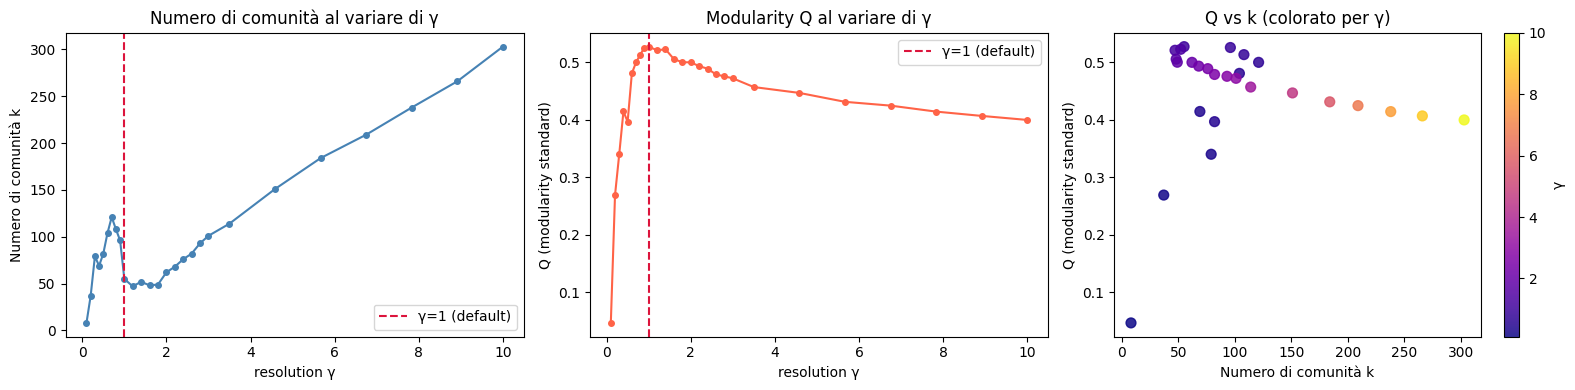


Punti notevoli:
 gamma    k      Q
   1.0 55.0 0.5274   ← Q massimo
 gamma  k      Q
   1.0 55 0.5274   ← γ=1 (default)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Grafico 1: k in funzione di γ
ax = axes[0]
ax.plot(res_df["gamma"], res_df["k"], color="steelblue", marker="o", markersize=4)
ax.axvline(1.0, color="crimson", linewidth=1.5, linestyle="--", label="γ=1 (default)")
ax.set_xlabel("resolution γ")
ax.set_ylabel("Numero di comunità k")
ax.set_title("Numero di comunità al variare di γ")
ax.legend()

# Grafico 2: Q (standard) in funzione di γ
ax2 = axes[1]
ax2.plot(res_df["gamma"], res_df["Q"], color="tomato", marker="o", markersize=4)
ax2.axvline(1.0, color="crimson", linewidth=1.5, linestyle="--", label="γ=1 (default)")
ax2.set_xlabel("resolution γ")
ax2.set_ylabel("Q (modularity standard)")
ax2.set_title("Modularity Q al variare di γ")
ax2.legend()

# Grafico 3: Q in funzione di k (ogni punto = un γ diverso)
ax3 = axes[2]
sc = ax3.scatter(res_df["k"], res_df["Q"], c=res_df["gamma"],
                 cmap="plasma", s=50, alpha=0.85)
plt.colorbar(sc, ax=ax3, label="γ")
ax3.set_xlabel("Numero di comunità k")
ax3.set_ylabel("Q (modularity standard)")
ax3.set_title("Q vs k (colorato per γ)")

plt.tight_layout()
plt.show()

# Tabella riassuntiva dei punti notevoli
print("\nPunti notevoli:")
print(res_df.loc[res_df["Q"].idxmax()].to_frame().T.to_string(index=False),
      "  ← Q massimo")
print(res_df[res_df["gamma"]==1.0].to_string(index=False),
      "  ← γ=1 (default)")


### 9.2 Trovare automaticamente il γ più vicino a un k target

Funzione di utilità: dato un numero di comunità desiderato, cerca il valore di γ
che lo approssima meglio tramite ricerca binaria.


In [8]:
def find_resolution_for_k(g, k_target, gamma_min=0.05, gamma_max=20.0,
                           n_iter=30, seed=RNG_SEED):
    """
    Ricerca binaria su γ per avvicinarsi il più possibile a k_target comunità.
    Restituisce (gamma_best, k_found, membership).
    """
    lo, hi = gamma_min, gamma_max
    best_gamma, best_memb, best_k = gamma_min, None, None

    for _ in range(n_iter):
        mid = (lo + hi) / 2
        np.random.seed(seed)
        vc_m = g.community_multilevel(weights=None, resolution=mid)
        k_m  = len(set(vc_m.membership))

        if best_memb is None or abs(k_m - k_target) < abs(best_k - k_target):
            best_gamma, best_memb, best_k = mid, vc_m.membership, k_m

        if k_m < k_target:
            lo = mid          # aumenta γ per ottenere più comunità
        elif k_m > k_target:
            hi = mid          # diminuisci γ per ottenere meno comunità
        else:
            break             # trovato esattamente k_target

    return best_gamma, best_k, best_memb


# Esempio: cerchiamo partizioni con 2, 4, 6, 8 comunità
print(f"{'k_target':>10} {'γ trovato':>12} {'k ottenuto':>12} {'Q':>8}")
print("-" * 46)
for k_target in [2, 4, 6, 8, 10]:
    gamma_f, k_f, memb_f = find_resolution_for_k(g, k_target)
    Q_f = g.modularity(memb_f)
    print(f"{k_target:>10} {gamma_f:>12.4f} {k_f:>12} {Q_f:>8.4f}")


  k_target    γ trovato   k ottenuto        Q
----------------------------------------------
         2       0.0512            2   0.0005
         4       0.0695            4   0.0012
         6       0.0890            6   0.0069
         8       0.0987            8   0.0468
        10       0.1279           10   0.0653


### 9.3 Taglio del dendrogramma — k comunità esatte

`g.community_multilevel()` costruisce internamente una gerarchia di aggregazioni
(una per ogni iterazione Phase 1 + Phase 2). Con il metodo `.as_clustering(n)`
si ottiene la partizione con esattamente **n comunità** a quel livello gerarchico.

⚠️ Il numero massimo di livelli è limitato dalla struttura della rete; non sempre
tutti i valori di k sono raggiungibili tramite dendrogramma.


In [9]:
# Run Louvain con return_levels=True per avere tutti i livelli gerarchici
vc_hier = g.community_multilevel(weights=None, return_levels=True)

print(f"Livelli gerarchici disponibili: {len(vc_hier)}")
print()
hier_rows = []
for level, vc_l in enumerate(vc_hier):
    memb_l = vc_l.membership
    k_l    = len(set(memb_l))
    Q_l    = g.modularity(memb_l)
    nmi_l  = ig.compare_communities(gt_membership, memb_l, method="nmi")
    hier_rows.append({"livello": level, "k": k_l,
                      "Q": round(Q_l, 4), "NMI_vs_AB": round(nmi_l, 4)})

hier_df = pd.DataFrame(hier_rows)
display(hier_df)


Livelli gerarchici disponibili: 4



NameError: name 'gt_membership' is not defined

NameError: name 'hier_df' is not defined

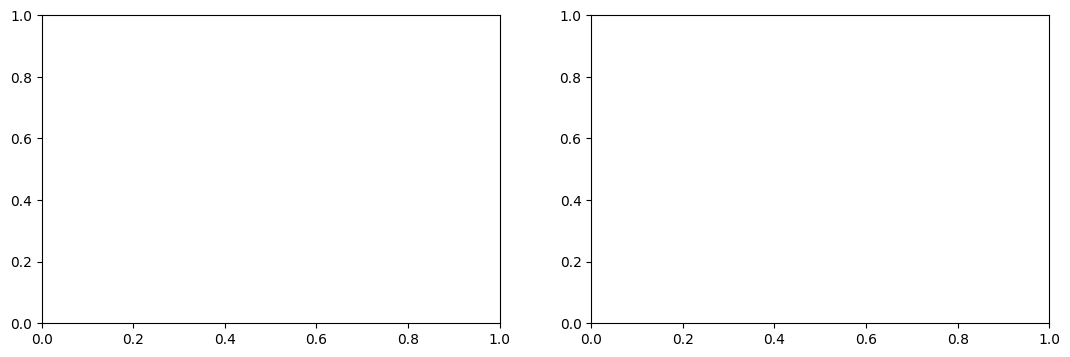

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(hier_df["livello"], hier_df["k"], color="steelblue",
        marker="o", markersize=6, linewidth=2)
ax.set_xlabel("Livello gerarchico")
ax.set_ylabel("Numero di comunità k")
ax.set_title("k per livello gerarchico Louvain")
for _, row in hier_df.iterrows():
    ax.annotate(f"k={int(row['k'])}", (row["livello"], row["k"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8)

ax2 = axes[1]
color_Q   = "tomato"
color_NMI = "steelblue"
l1, = ax2.plot(hier_df["livello"], hier_df["Q"], color=color_Q,
               marker="o", markersize=6, linewidth=2, label="Q")
ax2.set_xlabel("Livello gerarchico")
ax2.set_ylabel("Q (modularity)", color=color_Q)
ax2.tick_params(axis="y", labelcolor=color_Q)
ax2_twin = ax2.twinx()
l2, = ax2_twin.plot(hier_df["livello"], hier_df["NMI_vs_AB"], color=color_NMI,
                    marker="s", markersize=6, linewidth=2, linestyle="--",
                    label="NMI vs A/B")
ax2_twin.set_ylabel("NMI vs ground truth A/B", color=color_NMI)
ax2_twin.tick_params(axis="y", labelcolor=color_NMI)
ax2.set_title("Q e NMI per livello gerarchico")
lines = [l1, l2]
ax2.legend(lines, [l.get_label() for l in lines], loc="center right")

plt.tight_layout()
plt.show()

# Stampa il livello con Q massimo e quello più vicino a k=2
print(f"Livello con Q massimo : {hier_df.loc[hier_df['Q'].idxmax(), 'livello']}  "
      f"(k={hier_df.loc[hier_df['Q'].idxmax(), 'k']}, Q={hier_df['Q'].max():.4f})")
print(f"Livello più vicino a k=2: {hier_df.iloc[(hier_df['k']-2).abs().argsort()[:1]]['livello'].values[0]}  "
      f"(k={hier_df.iloc[(hier_df['k']-2).abs().argsort()[:1]]['k'].values[0]})")


---
## 8. Interpretazione

### Phase 1 e Phase 2 sul toy graph
Sul grafo a 8 nodi (2×K₄ + bridge) Phase 1 individua immediatamente i due cluster
naturali: ogni nodo preferisce stare con i propri 3 vicini dentro K₄ piuttosto che
attraversare il bridge. La supernetwork risultante ha solo 2 super-nodi e un unico
arco con peso 1 (il bridge). Phase 2 non produce ulteriori merge — la partizione è
già ottima.

### Louvain su climate_19
- **Q elevato** rispetto alla baseline casuale (vedere NB13-Sezione3): la struttura
  comunitaria è genuina.
- **Più di 2 comunità**: Louvain risolve la rete a granularità più fine rispetto alla
  semplice dicotomia A/B. Esistono sotto-bolle all'interno dei due grandi gruppi —
  il *resolution limit* (Sezione 8 di NS13) può però causare frammentazione artificiale
  delle comunità più piccole.
- **Stabilità**: Q varia poco tra i 30 seed (std basso), ma il numero di comunità
  e i dettagli del membership possono cambiare — degeneracy tipica di Louvain.

### Confronto con ground truth A/B
- **NMI** misura quanto la partizione Louvain "spiega" la label A/B: un valore
  elevato indica che le comunità Louvain si allineano bene con la polarizzazione
  A/B, anche se le suddividono ulteriormente.
- **ARI** conferma o smentisce il risultato: se è vicino a NMI, le due metriche
  concordano.
- Le comunità *dominanti A* e *dominanti B* corrispondono alle due bolle informative
  del dibattito climatico 2019 — ma Louvain rivela anche struttura interna fine
  che la semplice etichetta A/B non cattura.

### Louvain vs Leiden
Come notato nel tutorial, Louvain può produrre comunità internamente disconnesse
(un difetto strutturale). L'algoritmo **Leiden** (`g.community_leiden()` in igraph)
risolve questo problema ed è oggi la scelta preferita in pratica — prova a
sostituire `community_multilevel` con `community_leiden` e confronta i risultati!

### Resolution e numero di comunità
Il parametro `resolution` γ permette di controllare la granularità della partizione.
Per `climate_19`:
- **γ < 1**: la rete viene compressa in pochissime macro-comunità — utile se si vuole
  la sola dicotomia pro-clima / scettici.
- **γ = 1** (default): bilancio ottimale secondo la formulazione standard di Q.
- **γ > 1**: emergono sotto-bolle all'interno dei due grandi gruppi — potenzialmente
  interessanti per identificare diverse correnti di pensiero o cluster geografici/tematici.

Il grafico Q vs k mostra che spesso **Q ha un plateau** in un certo range di k: non c'è
un unico "numero giusto" di comunità, ma una famiglia di soluzioni ugualmente valide
dal punto di vista della modularity.
